# Clustering inicial de películas + espacio de trabajo para PCA

Este notebook centraliza dos cosas para el equipo:

1. **Clustering inicial** sobre `movies_2026.csv` (pipeline + comparación de algoritmos).
2. **Sección base de PCA** para análisis y visualización posterior en el mismo archivo.

Alcance de esta versión:
- preparar variables numéricas + categóricas simples,
- comparar algoritmos escalables de clustering,
- etiquetar clusters y generar perfiles básicos,
- dejar una base reproducible para PCA dentro del notebook.

Nota:
- La ingeniería avanzada de texto/multivalor (`genres`, `actors`, etc.) se mantiene fuera de este notebook para conservarlo manejable.


In [1]:
# Ejecutar una sola vez por entorno (puede tardar unos minutos).
%pip install pandas numpy scikit-learn matplotlib seaborn jupyter


In [2]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


In [3]:
CSV_PATH = Path('/tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026.csv')
if not CSV_PATH.exists():
    # Fallback útil si el repo se clona en otra ruta.
    local_candidate = Path.cwd() / 'movies_2026.csv'
    if local_candidate.exists():
        CSV_PATH = local_candidate

OUTPUT_PATH = Path('/tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026_clusters_initial.csv')
if not OUTPUT_PATH.parent.exists():
    OUTPUT_PATH = Path.cwd() / 'movies_2026_clusters_initial.csv'

REQUIRED_COLUMNS = [
    'id', 'title', 'budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
    'castWomenAmount', 'castMenAmount', 'releaseYear', 'originalLanguage', 'video'
]

NUMERIC_COLS = [
    'budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
    'castWomenAmount', 'castMenAmount', 'releaseYear'
]

CATEGORICAL_COLS = ['originalLanguage', 'video']
LOG_COLS = ['budget', 'revenue', 'popularity', 'voteCount']


def read_csv_robusto(path: Path) -> pd.DataFrame:
    read_kwargs = {
        'na_values': ['NA', ''],
        'keep_default_na': True,
        'low_memory': False,
    }
    try:
        return pd.read_csv(path, encoding='utf-8', encoding_errors='replace', **read_kwargs)
    except TypeError:
        # Compatibilidad con versiones de pandas sin encoding_errors.
        with open(path, 'r', encoding='utf-8', errors='replace', newline='') as f:
            return pd.read_csv(f, **read_kwargs)


def validate_required_columns(df) -> None:
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f'Faltan columnas requeridas: {missing}')


def normalize_video(series) -> pd.Series:
    s = series.copy()
    s = s.astype('string').str.strip().str.upper()
    s = s.fillna('UNKNOWN')
    s = s.replace({'': 'UNKNOWN', '<NA>': 'UNKNOWN', 'NA': 'UNKNOWN'})
    return s


def bucket_top_languages(series, top_n=10) -> pd.Series:
    s = series.astype('string').str.strip().str.lower().fillna('unknown')
    s = s.replace({'': 'unknown', 'na': 'unknown', '<na>': 'unknown'})
    top_values = s.value_counts(dropna=False).head(top_n).index
    s = s.where(s.isin(top_values), 'other')
    return s.str.upper()


def build_feature_dataframe(df) -> pd.DataFrame:
    out = df.copy()

    # Conversión numérica robusta.
    for col in NUMERIC_COLS:
        out[col] = pd.to_numeric(out[col], errors='coerce')

    # Normalización de categóricas simples.
    out['video'] = normalize_video(out['video'])
    out['originalLanguage'] = bucket_top_languages(out['originalLanguage'], top_n=10)

    # Evitar problemas con log1p en valores negativos.
    for col in LOG_COLS:
        out[col] = out[col].where(out[col].isna() | (out[col] >= 0), np.nan)
        out[col] = np.log1p(out[col])

    return out


def make_one_hot_encoder():
    # Compatibilidad sklearn: sparse_output (nuevo) vs sparse (antiguo).
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else np.asarray(X)


def build_kmeans(n_clusters: int, random_state: int):
    try:
        return KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    except TypeError:
        return KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)


def build_minibatch_kmeans(n_clusters: int, random_state: int):
    try:
        return MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init='auto',
            batch_size=1024,
        )
    except TypeError:
        return MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=10,
            batch_size=1024,
        )


def build_birch(n_clusters: int, random_state: int):
    # random_state no aplica a Birch; se mantiene en la firma para homogeneidad.
    _ = random_state
    return Birch(n_clusters=n_clusters, threshold=0.5, branching_factor=50)


def evaluate_algorithm_grid(X_transformed, configs, k_values, random_state=42) -> pd.DataFrame:
    records = []
    n_samples = X_transformed.shape[0]

    for algorithm_name, cfg in configs.items():
        builder = cfg['builder']

        for k in k_values:
            t0 = time.perf_counter()
            row = {
                'algorithm': algorithm_name,
                'k': int(k),
                'status': 'ok',
                'silhouette_score': np.nan,
                'calinski_harabasz_score': np.nan,
                'davies_bouldin_score': np.nan,
                'inertia': np.nan,
                'runtime_sec': np.nan,
                'n_clusters_efectivos': np.nan,
                'cluster_max_share': np.nan,
                'error': None,
            }
            try:
                model = builder(int(k), random_state)
                if hasattr(model, 'fit_predict'):
                    labels = model.fit_predict(X_transformed)
                else:
                    model.fit(X_transformed)
                    labels = getattr(model, 'labels_', None)
                    if labels is None:
                        raise RuntimeError('El modelo no expuso etiquetas de cluster')

                elapsed = time.perf_counter() - t0
                labels = np.asarray(labels)
                unique_labels, counts = np.unique(labels, return_counts=True)
                n_eff = int(len(unique_labels))
                max_share = float(counts.max() / counts.sum()) if counts.size else np.nan
                row.update({
                    'runtime_sec': elapsed,
                    'n_clusters_efectivos': n_eff,
                    'cluster_max_share': max_share,
                    'inertia': float(getattr(model, 'inertia_', np.nan)) if hasattr(model, 'inertia_') else np.nan,
                })

                if n_eff < 2:
                    row['status'] = 'invalid_clusters'
                    records.append(row)
                    continue

                sil_kwargs = {}
                if n_samples > 5000:
                    sil_kwargs = {'sample_size': 5000, 'random_state': random_state}

                row['silhouette_score'] = float(silhouette_score(X_transformed, labels, **sil_kwargs))
                row['calinski_harabasz_score'] = float(calinski_harabasz_score(X_transformed, labels))
                row['davies_bouldin_score'] = float(davies_bouldin_score(X_transformed, labels))
            except Exception as exc:
                row['status'] = 'error'
                row['runtime_sec'] = time.perf_counter() - t0
                row['error'] = str(exc)

            records.append(row)

    return pd.DataFrame(records)


def select_best_model(results_df) -> dict:
    if results_df.empty:
        raise ValueError('No hay resultados para seleccionar modelo.')

    valid = results_df.copy()
    valid = valid[(valid['status'] == 'ok') & results_df['silhouette_score'].notna()].copy()
    valid = valid[valid['n_clusters_efectivos'] >= 2]

    if valid.empty:
        debug_cols = ['algorithm', 'k', 'status', 'error']
        raise ValueError('No hubo combinaciones válidas. Revisar resultados.\n' + str(results_df[debug_cols].head(20)))

    non_degenerate = valid[valid['cluster_max_share'] <= 0.95].copy()
    candidate_pool = non_degenerate if not non_degenerate.empty else valid

    candidate_pool = candidate_pool.sort_values(
        by=['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score'],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    best = candidate_pool.iloc[0].to_dict()
    best['degenerate_filter_applied'] = bool(not non_degenerate.empty)
    return best


def profile_clusters(df_labels, numeric_cols, categorical_cols) -> dict:
    output = {}
    output['numeric_mean'] = df_labels.groupby('cluster_label')[numeric_cols].mean(numeric_only=True)
    output['numeric_median'] = df_labels.groupby('cluster_label')[numeric_cols].median(numeric_only=True)

    categorical_profiles = {}
    for col in categorical_cols:
        freq = pd.crosstab(df_labels['cluster_label'], df_labels[col], normalize='index')
        categorical_profiles[col] = freq.sort_index(axis=1)

    output['categorical'] = categorical_profiles
    return output


In [4]:
print(f'Leyendo dataset desde: {CSV_PATH}')
df_raw = read_csv_robusto(CSV_PATH)
print('Shape inicial:', df_raw.shape)
validate_required_columns(df_raw)

missing_summary = df_raw[REQUIRED_COLUMNS].isna().sum().sort_values(ascending=False)
print('\\nFaltantes (columnas requeridas):')
display(missing_summary.to_frame('missing_count'))

dup_mask = df_raw['id'].duplicated(keep='first')
dup_count = int(dup_mask.sum())
print(f'\\nDuplicados por id detectados: {dup_count}')
if dup_count > 0:
    df_raw = df_raw.loc[~dup_mask].copy()
    print('Shape tras eliminar duplicados (manteniendo la primera ocurrencia):', df_raw.shape)


Leyendo dataset desde: /tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026.csv
Shape inicial: (19883, 28)
\nFaltantes (columnas requeridas):


,missing_count
video,486
castMenAmount,162
castWomenAmount,37
releaseYear,2
title,1
productionCoAmount,0
originalLanguage,0
actorsAmount,0
productionCountriesAmount,0
id,0


\nDuplicados por id detectados: 0


In [5]:
# Construcción del dataset de trabajo para clustering.
df_model = build_feature_dataframe(df_raw)

feature_cols = NUMERIC_COLS + CATEGORICAL_COLS
df_features = df_model[['id', 'title'] + feature_cols].copy()

print('Vista previa de features preparadas:')
display(df_features.head())
print('\\nResumen rápido de dtypes:')
display(df_features[feature_cols].dtypes.to_frame('dtype'))


Vista previa de features preparadas:


,id,title,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear,originalLanguage,video
0,1627085,Immersed,0.0,0.0,95,0.035078,0.0,0.0,2,0,0,8,2.0,5.0,2026.0,OTHER,FALSE
1,1626914,Cinderella,0.0,0.0,3,0.035078,0.0,0.0,1,0,0,4,0.0,0.0,2026.0,EN,FALSE
2,1626898,Aladdin,0.0,0.0,2,0.021174,0.0,0.0,1,0,0,3,0.0,0.0,2026.0,EN,FALSE
3,1626808,THE RING AND THE DECK,0.0,0.0,5,0.042005,0.0,0.0,3,0,0,7,0.0,0.0,2026.0,ES,FALSE
4,1626678,Crimson High 3,0.0,0.0,12,0.037199,0.0,0.0,1,0,0,3,0.0,0.0,2026.0,EN,FALSE


\nResumen rápido de dtypes:


,dtype
budget,float64
revenue,float64
runtime,int64
popularity,float64
voteAvg,float64
voteCount,float64
genresAmount,int64
productionCoAmount,int64
productionCountriesAmount,int64
actorsAmount,int64


In [6]:
# Preprocesamiento reproducible (numéricas + categóricas simples).
# FunctionTransformer se importa para mantener compatibilidad con el plan; aquí se usa como paso explícito de identidad.
identity_transformer = FunctionTransformer(lambda x: x, validate=False)

numeric_pipeline = Pipeline(steps=[
    ('identity', identity_transformer),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot', make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_COLS),
        ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ],
    remainder='drop',
)

X_input = df_features[feature_cols].copy()
X_transformed = preprocessor.fit_transform(X_input)
X_model = to_dense(X_transformed)

print('Forma de X preprocesada (densa para métricas/modelos):', X_model.shape)


Forma de X preprocesada (densa para métricas/modelos): (19883, 27)


In [7]:
algorithm_configs = {
    'KMeans': {'builder': build_kmeans},
    'MiniBatchKMeans': {'builder': build_minibatch_kmeans},
    'Birch': {'builder': build_birch},
}

k_values = list(range(2, 11))

results_df = evaluate_algorithm_grid(
    X_transformed=X_model,
    configs=algorithm_configs,
    k_values=k_values,
    random_state=RANDOM_STATE,
)

print('Resultados del grid (top 15 por silhouette):')
display(
    results_df.sort_values(
        by=['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score'],
        ascending=[False, False, True]
    ).head(15)
)

print('\\nResumen por estado:')
display(results_df['status'].value_counts(dropna=False).to_frame('count'))


Resultados del grid (top 15 por silhouette):


,algorithm,k,status,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia,runtime_sec,n_clusters_efectivos,cluster_max_share,error
0,KMeans,2,ok,0.796884,1442.788680,0.412095,253367.416212,0.100811,2,0.998391,None
20,Birch,4,ok,0.594220,1872.476778,0.812123,NaN,0.645190,4,0.975054,None
19,Birch,3,ok,0.592076,1794.640614,0.919571,NaN,0.642629,3,0.976714,None
18,Birch,2,ok,0.584203,1803.996542,1.062822,NaN,0.829523,2,0.982095,None
9,MiniBatchKMeans,2,ok,0.386521,9834.609142,1.102256,181854.637721,0.006800,2,0.502439,None
1,KMeans,3,ok,0.381126,7250.508567,1.474017,157135.623029,0.010578,3,0.474224,None
10,MiniBatchKMeans,3,ok,0.379290,7241.916330,1.461095,157501.036885,0.005824,3,0.477292,None
26,Birch,10,ok,0.374220,4812.439949,0.863439,NaN,0.647289,10,0.494744,None
25,Birch,9,ok,0.373035,5216.310246,0.941156,NaN,0.626316,9,0.494744,None
24,Birch,8,ok,0.372031,5602.281166,1.059010,NaN,0.631314,8,0.494744,None


\nResumen por estado:


,count
status,
ok,27


In [8]:
best_selection = select_best_model(results_df)
print('Mejor configuración seleccionada:')
display(pd.Series(best_selection))

best_algorithm = best_selection['algorithm']
best_k = int(best_selection['k'])

best_model = algorithm_configs[best_algorithm]['builder'](best_k, RANDOM_STATE)
if hasattr(best_model, 'fit_predict'):
    final_labels = best_model.fit_predict(X_model)
else:
    best_model.fit(X_model)
    final_labels = best_model.labels_

final_labels = np.asarray(final_labels, dtype=int)

df_clustered = df_model.copy()
df_clustered['cluster_label'] = final_labels

df_output = df_clustered[['id', 'title', 'cluster_label']].copy()
df_output['best_algorithm'] = best_algorithm
df_output['best_k'] = best_k

print('Vista previa de salida etiquetada:')
display(df_output.head())


Mejor configuración seleccionada:


algorithm                    MiniBatchKMeans
k                                          2
status                                    ok
silhouette_score                    0.386521
calinski_harabasz_score          9834.609142
davies_bouldin_score                1.102256
inertia                        181854.637721
runtime_sec                           0.0068
n_clusters_efectivos                       2
cluster_max_share                   0.502439
error                                   None
degenerate_filter_applied               True
dtype: object

Vista previa de salida etiquetada:


,id,title,cluster_label,best_algorithm,best_k
0,1627085,Immersed,0,MiniBatchKMeans,2
1,1626914,Cinderella,0,MiniBatchKMeans,2
2,1626898,Aladdin,0,MiniBatchKMeans,2
3,1626808,THE RING AND THE DECK,0,MiniBatchKMeans,2
4,1626678,Crimson High 3,0,MiniBatchKMeans,2


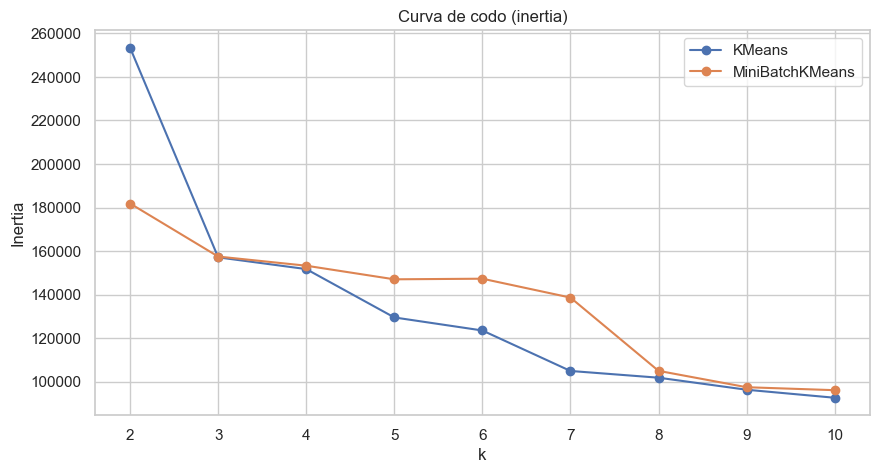

In [9]:
# Curva de codo (inertia) para KMeans y MiniBatchKMeans.
elbow_df = results_df[
    (results_df['algorithm'].isin(['KMeans', 'MiniBatchKMeans'])) &
    (results_df['status'] == 'ok') &
    (results_df['inertia'].notna())
].copy()

plt.figure(figsize=(10, 5))
for alg, part in elbow_df.groupby('algorithm'):
    part = part.sort_values('k')
    plt.plot(part['k'], part['inertia'], marker='o', label=alg)
plt.title('Curva de codo (inertia)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.legend()
plt.show()


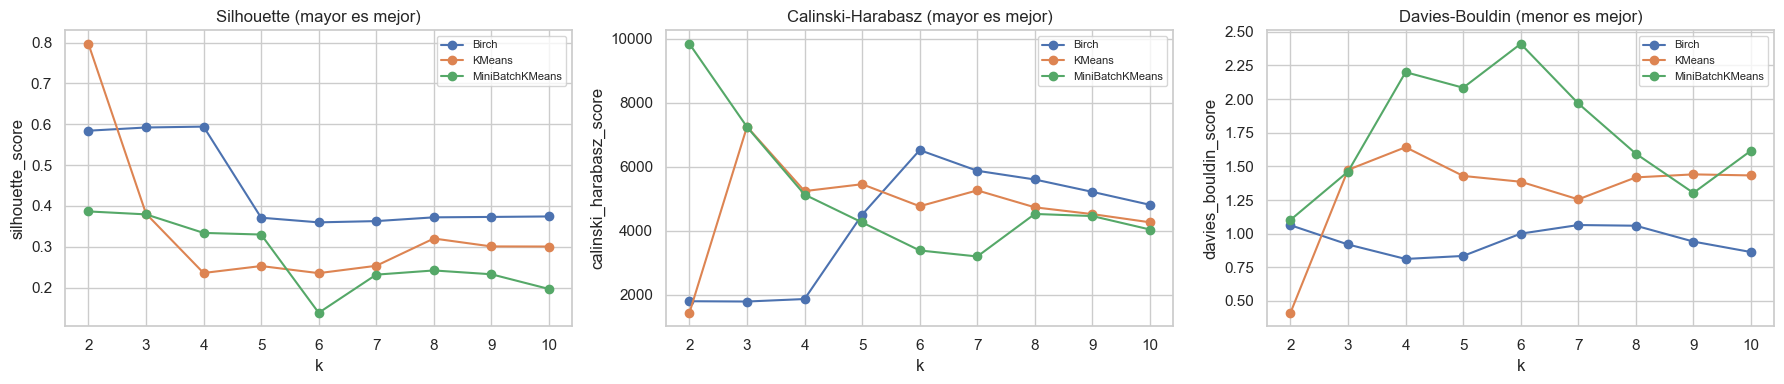

In [10]:
# Métricas internas vs k por algoritmo.
metrics_to_plot = [
    ('silhouette_score', 'Silhouette (mayor es mejor)'),
    ('calinski_harabasz_score', 'Calinski-Harabasz (mayor es mejor)'),
    ('davies_bouldin_score', 'Davies-Bouldin (menor es mejor)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_df = results_df[results_df['status'] == 'ok'].copy()

for ax, (metric_col, title) in zip(axes, metrics_to_plot):
    for alg, part in plot_df.groupby('algorithm'):
        part = part.sort_values('k')
        ax.plot(part['k'], part[metric_col], marker='o', label=alg)
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel(metric_col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


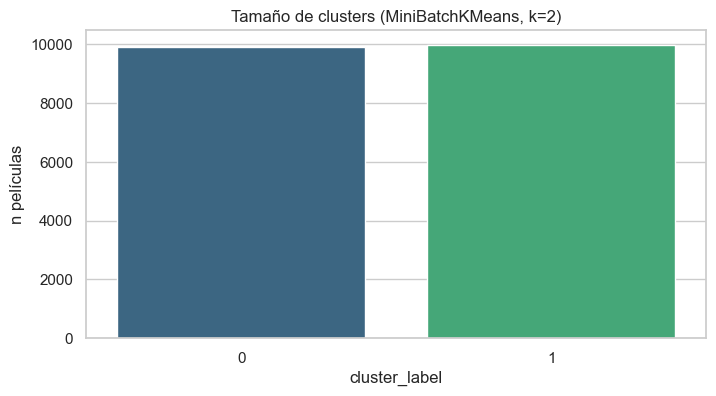

Tamaños de cluster:


,count,share
cluster_label,,
0,9893,0.497561
1,9990,0.502439


In [11]:
# Distribución de tamaños del modelo ganador.
cluster_size = df_clustered['cluster_label'].value_counts().sort_index()
cluster_share = (cluster_size / cluster_size.sum()).rename('share')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=cluster_size.index.astype(str), y=cluster_size.values, ax=ax, palette='viridis')
ax.set_title(f'Tamaño de clusters ({best_algorithm}, k={best_k})')
ax.set_xlabel('cluster_label')
ax.set_ylabel('n películas')
plt.show()

print('Tamaños de cluster:')
display(pd.DataFrame({'count': cluster_size, 'share': cluster_share}).sort_index())


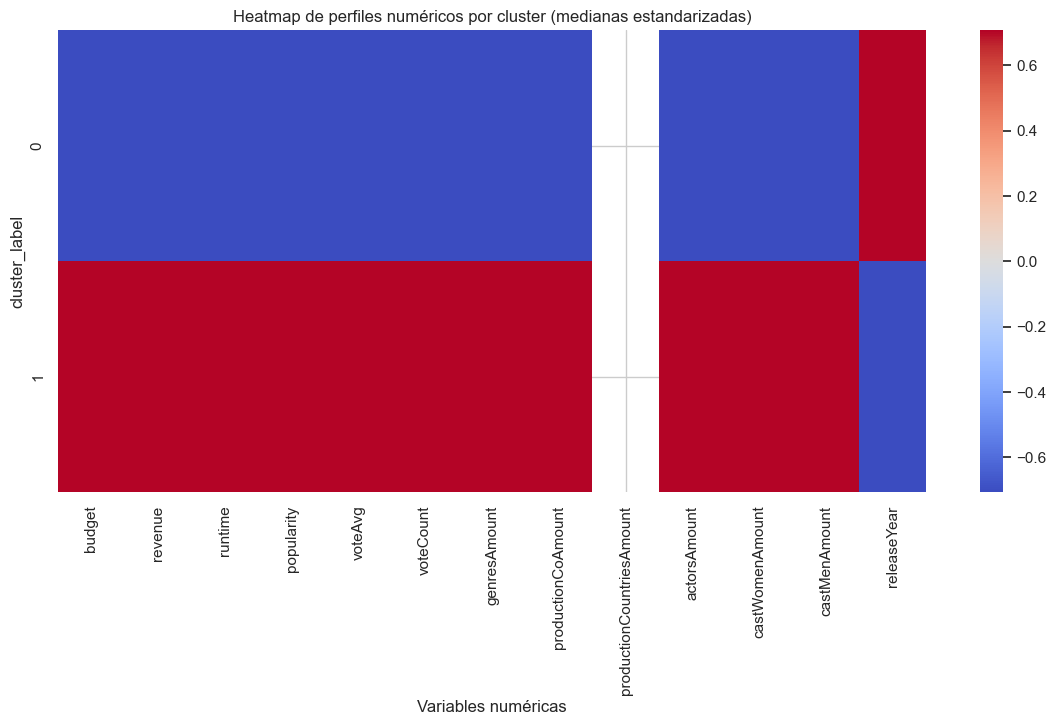

Perfiles numéricos (medianas):


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
cluster_label,,,,,,,,,,,,,
0,0.000000,0.000000,10.0,0.052877,0.0000,0.000000,1.0,0.0,1.0,3.0,0.0,0.0,2025.0
1,13.574648,12.383242,100.0,3.125905,6.5025,6.035481,3.0,3.0,1.0,21.0,6.0,11.0,2013.0


\nDistribución relativa por cluster - originalLanguage


originalLanguage,DE,EN,ES,FR,IT,JA,KO,NL,OTHER,PT,ZH
cluster_label,,,,,,,,,,,
0,0.038108,0.423734,0.086223,0.083190,0.020216,0.023552,0.017285,0.017588,0.205903,0.059638,0.024563
1,0.008408,0.777678,0.038539,0.027127,0.010210,0.063564,0.016517,0.001802,0.040140,0.003804,0.012212


\nDistribución relativa por cluster - video


video,FALSE,TRUE,UNKNOWN
cluster_label,,,
0,0.998686,0.001011,0.000303
1,0.944244,0.007407,0.048348


In [12]:
profiles = profile_clusters(df_clustered, NUMERIC_COLS, CATEGORICAL_COLS)

numeric_profile = profiles['numeric_median'].copy()
if numeric_profile.shape[0] >= 2:
    # Estandarización por columna para hacer comparables magnitudes en el heatmap.
    denom = numeric_profile.std(axis=0).replace(0, np.nan)
    numeric_profile_z = (numeric_profile - numeric_profile.mean(axis=0)) / denom
else:
    numeric_profile_z = numeric_profile.copy()

plt.figure(figsize=(14, 6))
sns.heatmap(numeric_profile_z, cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap de perfiles numéricos por cluster (medianas estandarizadas)')
plt.xlabel('Variables numéricas')
plt.ylabel('cluster_label')
plt.show()

print('Perfiles numéricos (medianas):')
display(profiles['numeric_median'])

for cat_col, cat_table in profiles['categorical'].items():
    print(f'\\nDistribución relativa por cluster - {cat_col}')
    display(cat_table)


## PCA (espacio de trabajo del equipo)

Esta sección deja una base funcional para trabajar PCA **en el mismo notebook** usando las features ya preprocesadas (`X_model`) y las etiquetas de clustering (`cluster_label`).

Sugerencias para el equipo:
- ajustar el número de componentes según la varianza explicada,
- comparar proyecciones PCA con los clusters obtenidos,
- probar otras visualizaciones o criterios de interpretación.


In [13]:
# PCA: varianza explicada y número de componentes sugerido.
max_pca_components = min(X_model.shape[0], X_model.shape[1])
pca_full = PCA(n_components=max_pca_components, random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_model)

explained_ratio = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained_ratio)

pca_summary = pd.DataFrame({
    'component': np.arange(1, len(explained_ratio) + 1),
    'explained_variance_ratio': explained_ratio,
    'cumulative_explained_variance': cumulative_explained,
})

n_comp_80 = int(np.argmax(cumulative_explained >= 0.80) + 1) if np.any(cumulative_explained >= 0.80) else len(cumulative_explained)
n_comp_90 = int(np.argmax(cumulative_explained >= 0.90) + 1) if np.any(cumulative_explained >= 0.90) else len(cumulative_explained)
n_comp_95 = int(np.argmax(cumulative_explained >= 0.95) + 1) if np.any(cumulative_explained >= 0.95) else len(cumulative_explained)

print(f'Componentes para >=80% varianza explicada: {n_comp_80}')
print(f'Componentes para >=90% varianza explicada: {n_comp_90}')
print(f'Componentes para >=95% varianza explicada: {n_comp_95}')

display(pca_summary.head(15))


Componentes para >=80% varianza explicada: 7
Componentes para >=90% varianza explicada: 10
Componentes para >=95% varianza explicada: 12


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.400493,0.400493
1,2,0.108480,0.508972
2,3,0.078753,0.587725
3,4,0.074301,0.662026
4,5,0.058671,0.720698
5,6,0.052753,0.773450
6,7,0.045044,0.818494
7,8,0.040155,0.858649
8,9,0.031224,0.889872
9,10,0.029733,0.919605


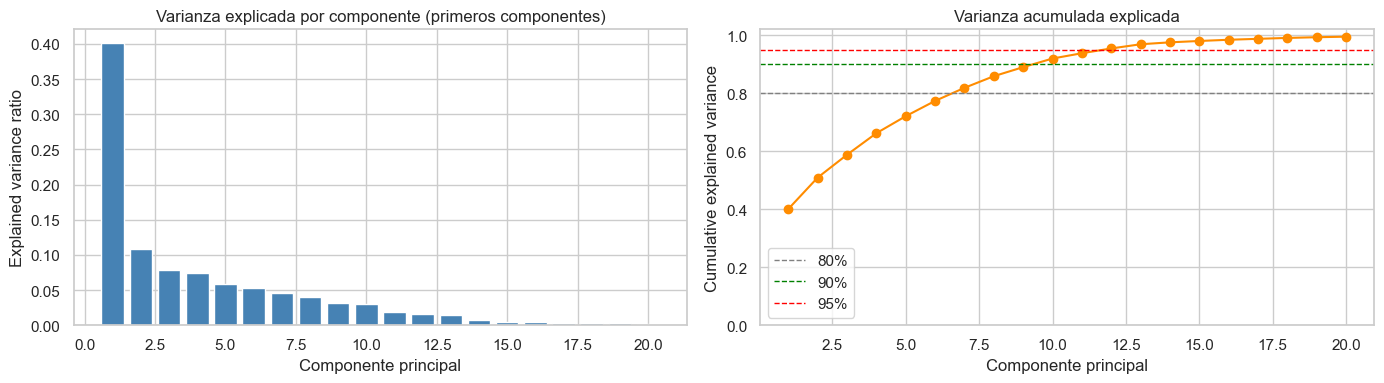

In [14]:
# Visualización de varianza explicada por componente.
max_plot_components = min(20, len(explained_ratio))
plot_df = pca_summary.head(max_plot_components)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(plot_df['component'], plot_df['explained_variance_ratio'], color='steelblue')
axes[0].set_title('Varianza explicada por componente (primeros componentes)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(plot_df['component'], plot_df['cumulative_explained_variance'], marker='o', color='darkorange')
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].axhline(0.90, color='green', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1, label='95%')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Varianza acumulada explicada')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()


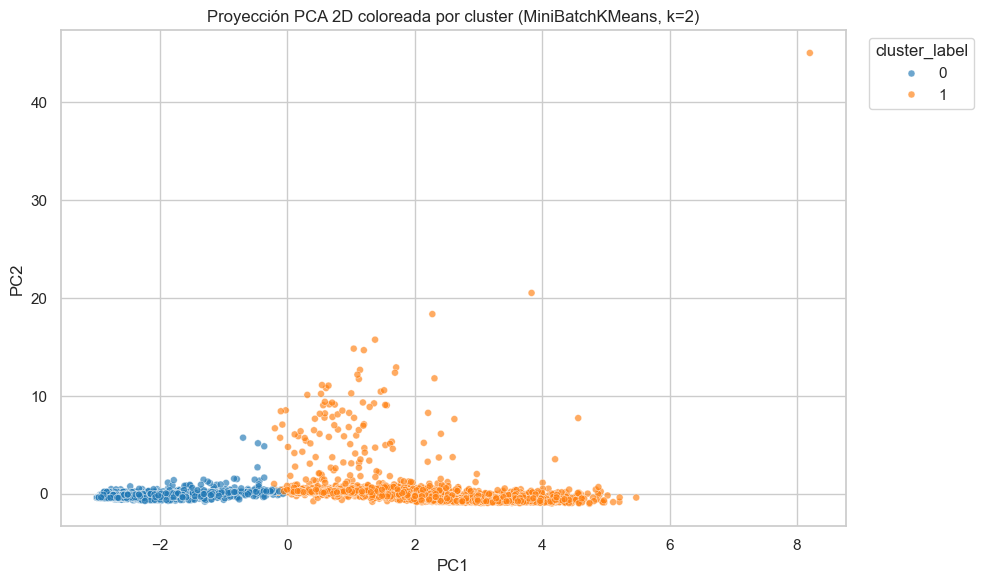

Varianza explicada por PC1 y PC2 (modelo de visualización 2D):


PC1    0.400493
PC2    0.108480
Name: explained_variance_ratio, dtype: float64

In [15]:
# Proyección PCA 2D para explorar clusters (muestra para visualización).
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_model)

pca_plot_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'cluster_label': df_clustered['cluster_label'].astype(str).values,
})

plot_n = min(5000, len(pca_plot_df))
if len(pca_plot_df) > plot_n:
    pca_plot_sample = pca_plot_df.sample(plot_n, random_state=RANDOM_STATE)
else:
    pca_plot_sample = pca_plot_df.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_plot_sample,
    x='PC1', y='PC2', hue='cluster_label',
    alpha=0.65, s=25, palette='tab10'
)
plt.title(f'Proyección PCA 2D coloreada por cluster ({best_algorithm}, k={best_k})')
plt.legend(title='cluster_label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Varianza explicada por PC1 y PC2 (modelo de visualización 2D):')
display(pd.Series(pca_2d.explained_variance_ratio_, index=['PC1', 'PC2'], name='explained_variance_ratio'))


In [16]:
# Exportación de etiquetas de clustering (activo por defecto).
df_output.to_csv(OUTPUT_PATH, index=False)
print(f'Archivo exportado: {OUTPUT_PATH.resolve()}')
print(f'Filas exportadas: {len(df_output):,}')


Archivo exportado: /private/tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026_clusters_initial.csv
Filas exportadas: 19,883
